Лабораторная работа по линейной алгебре и обработке данных: **Метод главных компонент(РСА)**

Подуровская Софья j3110

Expert: **Математическое обоснование оптимальности РСА:** оптимальные направления PCA совпадают с собственными векторами матрицы ковариаций.

центрированные данные - матрица $\tilde X$ размера $n\times m$

ковариационная матрица - $$C=\frac{1}{n-1}\,\tilde X^{\top}\tilde X,\qquad C^{\top}=C.$$

проекция - $\tilde X w$, где $w$ - единичный($\|w\|=1$)

Дисперсия проекции данных на единичный вектор $w$ равна:

$\mathrm{Var}(\tilde X w)=\frac{1}{n-1}\sum_{i=1}^{n}\bigl(\tilde x_i\cdot w\bigr)^2=\frac{1}{n-1}\|\tilde X w\|^2=w^\top C w$ \
Обозначим $q(w)=w^{\top}Cw$. Это квадратичная форма с симметричной матрицей $C$\
 Поэтому задача PCA сводится к максимизации
 КФ: $q(w)$ при $\|w\|=1$.

 Матрица $C$ симметрична, значит по теореме о диагонализации КФ в евклидовом пространстве в ОНБ её собственных векторов $v_1,\dots,v_m$:\
  форма принимает канонический вид: $q(w)=\sum_{j}\lambda_j t_j^2$, где $t_j$ - координаты $w$ в этом базисе, а $\lambda_j\ge 0$ — СЧ из уравнения $\det(C-\lambda E)=0$.

  Так как базис ортонормированный, то длина сохраняется и $\sum_j t_j^2=\|w\|^2=1$. \
  Упорядочив $\lambda_1\ge\lambda_2\ge\dots\ge\lambda_m$, получаем: $q(w)=\sum_j\lambda_j t_j^2\le\lambda_1\sum_j t_j^2=\lambda_1$, причём равенство достигается только при $t_1=\pm1$ и остальных $t_j=0$, то есть при $w=v_1$, значит направление максимальной дисперсии - это собственный вектор при наибольшем собственном значении $\lambda_1$.
  
  Для $k$-й компоненты, дополнительно требуя $w\perp v_1,\dots,v_{k-1}$, те же выкладки дают $q(w)=\sum_{j\ge k}\lambda_j t_j^2\le\lambda_k$ с равенством при $w=v_k$, что доказывает совпадение оптимальных направлений PCA с собственными векторами $C$ в порядке убывания $\lambda$, а $\lambda_j$ - дисперсии вдоль них. Доля объяснённой дисперсии первыми $k$ компонентами равна $\dfrac{\sum_{j\le k}\lambda_j}{\sum_{j}\lambda_j}$.

Предварительно реализовала класс матриц с функциями для:


*   задания элемента матрицы
*   арифметических операций(сложения, умножения на скаляр, матричное умножение)
* получения определителя
* транспонирования
* получения следа



In [1]:
from typing import List, Tuple
import math

class Matrix:
    def __init__(self, data):
        self.data = data
        self.rows = len(data)
        self.cols = len(data[0])

    def __getitem__(self, row: int):
        return self.data[row]

    def __add__(self, mat2: 'Matrix') -> 'Matrix':
        res = [[self.data[i][j] + mat2.data[i][j] for j in range(self.cols)] for i in range(self.rows)]
        return Matrix(res)

    def __mul__(self, c: float) -> 'Matrix':
        res = [[self.data[i][j]*c for j in range(self.cols)] for i in range(self.rows)]
        return Matrix(res)

    def __matmul__(self, mat2: 'Matrix') -> 'Matrix':
        if self.cols != mat2.rows:
            raise ValueError("Несовместимые размерности")
        res = []
        for i in range(self.rows):
            res_row = [sum(self.data[i][k] * mat2[k][j] for k in range(self.cols)) for j in range(mat2.cols)]
            res.append(res_row)
        return Matrix(res)

    def transpose(self) -> 'Matrix':
        res = [[self.data[j][i] for j in range(self.rows)] for i in range(self.cols)]
        return Matrix(res)

    def det(self):
        A = [row[:] for row in self.data]
        sign = 1
        #прямой ход - строим верхнетреугольную матрицу
        for k in range(self.rows):
            if abs(A[k][k]) < 1e-8:
                for i in range(k+1, len(A)):
                    if abs(A[i][k]) > 1e-8:
                        A[k], A[i] = A[i], A[k]
                        sign *= -1
                        break
            if abs(A[k][k]) < 1e-8:
                return 0.0
            for i in range(k+1, self.rows):
                factor = A[i][k] / A[k][k]
                for j in range(self.cols):
                    A[i][j] -= factor * A[k][j]
        diag = [A[i][i] for i in range(min(self.cols, self.rows))]
        res = 1.0
        for d in diag:
            res *= d
        return sign * res

    def trace(self):
        tr = sum(self.data[i][i] for i in range(self.rows))
        return tr

**Easy**

**Задание (Easy)**: Реализовать метод Гаусса для решения СЛАУ



In [2]:
def gauss_solver(A: 'Matrix', b: 'Matrix') -> List['Matrix']:
    """
    Вход:
    A: матрица коэффициентов (n*n). Используется класс Matrix из предыдущей
    лабораторной работы
    b: вектор правых частей (n*1)
    Выход:
    list[Matrix]: список базисных векторов решения системы
    Raises:
    ValueError: если система несовместна
    """
    A_copy = [row[:] for row in A.data]
    b_copy = [b[i][0] for i in range(A.rows)]
    #прямой ход - строим верхнетреугольную матрицу
    for k in range(A.rows):
        if abs(A_copy[k][k]) < 1e-8:
            for i in range(k+1, A.rows):
                if abs(A_copy[i][k]) > 1e-8:
                    A_copy[k], A_copy[i] = A_copy[i], A_copy[k]
                    b_copy[k], b_copy[i] = b_copy[i], b_copy[k]
                    break
        if abs(A_copy[k][k]) < 1e-8:
            continue
        for i in range(k+1, A.rows):
            factor = A_copy[i][k] / A_copy[k][k]
            for j in range(A.cols):
                A_copy[i][j] -= factor * A_copy[k][j]
            b_copy[i] -= factor * b_copy[k]
    #проверка на совместность и поиск свободных переменных
    pivot_cols = set()
    for i in range(A.rows):
        if all(abs(x) < 1e-8 for x in A_copy[i]) and abs(b_copy[i]) > 1e-8:
            raise ValueError("система несовместна")
        for j in range(A.cols):
            if abs(A_copy[i][j]) > 1e-8:
                pivot_cols.add(j)
                break
    free_cols = [j for j in range(A.cols) if j not in pivot_cols]
    #обратный ход
    basis = []
    pivot_cols = sorted(pivot_cols)
    for free_x in free_cols:
        x = [0] * A.cols
        x[free_x] = 1
        for i in range(len(pivot_cols) - 1, -1, -1):
            p = pivot_cols[i]
            x[p] = (b_copy[i] - sum(A_copy[i][j] * x[j] for j in range(A.cols) if j != p)) / A_copy[i][p]
        basis.append(Matrix([[v] for v in x]))
    if not free_cols:
        x = [0] * A.cols
        x[A.rows-1] = b_copy[A.rows-1] / A_copy[A.rows-1][A.rows-1]
        for i in range(A.cols - 2, -1, -1):
            x[i] = (b_copy[i] - sum(A_copy[i][j] * x[j] for j in range(i+1, A.cols))) / A_copy[i][i]
        return [Matrix([[v] for v in x])]
    return basis

**Задание (Easy):** Реализовать функцию центрирования данных:

$X_{centered} = X - mean(X)$

In [3]:
def center_data(X: 'Matrix') -> 'Matrix':
    """
    Вход: матрица данных X (n*m)
    Выход: центрированная матрица X_centered (n*m)
    """
    x_ = [sum(X.data[i][j] for i in range(X.rows)) / X.rows for j in range(X.cols)]
    res = [[X.data[i][j] - x_[j] for j in range(X.cols)] for i in range(X.rows)]
    return Matrix(res)

**Задание (Easy):** Вычислить матрицу ковариаций:
$C = \frac{1}{n-1}X^{T}X$

In [4]:
def covariance_matrix(X_centered: 'Matrix') -> 'Matrix':
    """
    Вход: центрированная матрица X_centered (n*m)
    Выход: матрица ковариаций C (m*m)
    """
    return (X_centered.transpose() @ X_centered) * (1 / (X_centered.rows - 1))

**Normal**

**Задание (Normal):** Найти собственные значения матрицы
$C$ методом бисекции:
$\det(C - \lambda I) = 0$

1. Отделяем корни: считаем $f(\lambda)$ в узлах мелкой сетки на отрезке $[-1,trace+1]$. Функция $f$ непрерывна, поэтому если на двух соседних узлах знаки разные, то между ними есть корень.
2. Внутри каждого отрезка уточняем корень **методом бисекции**: делим отрезок пополам и оставляем ту половину, где знак меняется, пока его длина не станет меньше tol.


In [5]:
def find_eigenvalues(C: 'Matrix', tol: float = 1e-8) -> List[float]:
    """
    Вход:
    C: матрица ковариаций (m*m)
    tol: допустимая погрешность
    Выход: список вещественных собственных значений
    """
    def f(l):
        """
        построение характеристического многочлена
        det(C − λI)
        """
        C_lambda = Matrix([[C.data[i][j] - l if i == j else C.data[i][j] for j in range(C.cols)] for i in range(C.rows)])
        har = C_lambda.det()
        return har
    #отрезок - от 0 до trace
    a = -1
    b = int(C.trace()) + 1
    sign_change = []
    lambdas = []
    val = [(i + 0.1)/1000 for i in range(a*1000, b*1000)]
    prev = f(val[0])
    for i in range(1, len(val)):
        curr = f(val[i])
        if curr*prev < 0:
            sign_change.append((val[i-1], val[i]))
        prev = curr
    #бисекция
    for start, finish in sign_change:
        err = finish - start
        while err > tol:
            c = (start + finish) / 2
            if abs(f(c)) < tol:
                break
            if f(start)*f(c) >= 0:
                start = c
            else:
                finish = c
            err = finish - start
        lambdas.append(c)
    lambdas.sort(reverse=True)
    return lambdas

**Задание (Normal):** Найти собственные векторы матрицы $C$:
$(C - \lambda I)v = 0$

Используем итерационный метод(обратную итерацию со сдвигом):

1. Берём матрицу $B = C - (\lambda+\varepsilon)I$ (сдвиг $\varepsilon=10^{-6}$ - чтобы $B$ была обратима).
2. Начинаем с вектора $x=(1,\dots,1)$ и 5 раз повторяем: решаем $B y = x$ (через gauss_solver), нормируем $x = y/\|y\|$.
3. После итераций $x$ сходится к собственному вектору при $\lambda$.

In [6]:
def find_eigenvectors(C: 'Matrix', eigenvalues: List[float]) -> List['Matrix']:
    """
    Вход:
    C: матрица ковариаций (m*m)
    eigenvalues: список собственных значений
    Выход: список собственных векторов (каждый вектор - объект Matrix)
    """
    eps = 1e-6
    basis = []
    for val in eigenvalues:
        shift = val + eps
        B = Matrix([[C.data[i][j] - shift if i == j else C.data[i][j] for j in range(C.cols)] for i in range(C.rows)])
        x = Matrix([[1.0] for _ in range(C.rows)])
        for _ in range(5):
            y = gauss_solver(B, x)[0]
            length = sum(v[0]**2 for v in y.data) ** 0.5
            x = Matrix([[v[0] / length] for v in y.data])
        basis.append(x)
    return basis

**Задание (Normal):** Вычислить долю объяснённой дисперсии:
$\gamma = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{m} \lambda_i}$


In [7]:
def explained_variance_ratio(eigenvalues: List[float], k: int) -> float:
    """
    Вход:
    eigenvalues: список собственных значений
    k: число компонент
    Выход: доля объяснённой дисперсии
    """
    return sum(eigenvalues[:k]) / sum(eigenvalues)

**Hard**

**Задание (Hard):** Реализовать полный алгоритм PCA:
1. Центрирование данных.
2. Вычисление матрицы выборочных ковариаций.
3. Нахождение собственных значений и векторов.
4. Проекция данных на главные компоненты.

In [8]:
def pca(X: 'Matrix', k: int = None) -> Tuple['Matrix', float]:
    """
    Вход:
    X: матрица данных (n*m)
    k: число главных компонент
    Выход:
    X_proj: проекция данных (n*k)
    : доля объяснённой дисперсии
    """
    X_centred = center_data(X)
    cov_X = covariance_matrix(X_centred)
    lambdas = find_eigenvalues(cov_X)
    if k is None:
        k = auto_select_k(lambdas)
    vectors = find_eigenvectors(cov_X, lambdas)
    X_proj = X_centred @ Matrix([[vectors[j].data[i][0] for j in range(k)] for i in range(X.cols)])
    return (X_proj, explained_variance_ratio(lambdas, k))

**Задание (Hard):**
Визуализировать проекцию данных на первые две главные компоненты.

In [9]:
from matplotlib.figure import Figure
import matplotlib.pyplot as plt

def plot_pca_projection(X_proj: 'Matrix') -> Figure:
    """
    Вход: проекция данных X_proj (n*2)
    Выход: объект Figure из Matplotlib
    """
    x = [X_proj.data[i][0] for i in range(X_proj.rows)]
    y = [X_proj.data[i][1] for i in range(X_proj.rows)]
    fig, ax = plt.subplots()
    ax.scatter(x, y)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title('PCA Projection')
    return fig

доля объясненной дисперсии: 98.3%


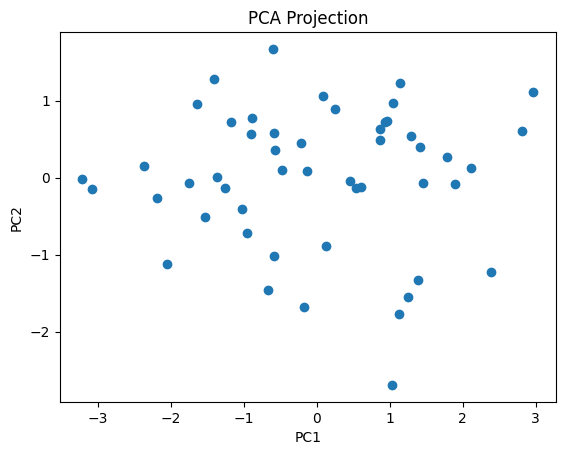

In [10]:
import random
random.seed(0)
data = [[random.gauss(0, 1), random.gauss(0, 1), 0.0] for _ in range(50)]
for row in data:
    row[2] = 0.8 * row[0] + 0.3 * random.gauss(0, 1)
X = Matrix(data)
proj, gamma = pca(X, 2)
fig = plot_pca_projection(proj)
print(f"доля объясненной дисперсии: {gamma:.1%}")

**Задание (Hard):** Вычислить среднеквадратическую ошибку
восстановления данных:
$\text{MSE} = \frac{1}{n \cdot m} \sum_{i,j} \left(X_{\text{orig}} - X_{\text{recon}}\right)^2$

In [11]:
def reconstruction_error(X_orig: 'Matrix', X_recon: 'Matrix') -> float:
    """
    Вход:
    X_orig: исходные данные (n*m)
    X_recon: восстановленные данные (n*m)
    Выход: среднеквадратическая ошибка MSE
    """
    mse = 1/(X_orig.cols * X_orig.rows) * sum((X_orig.data[i][j] - X_recon.data[i][j])**2 for j in range(X_orig.cols) for i in range(X_orig.rows))
    return mse

**Expert**

**Задание (Expert):** Добавить автоматический выбор числа
главных компонент на основе порога объяснённой дисперсии
(встроить это в реализованную функцию pca):

$$k = \min\left\{\, k : \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{m} \lambda_i} \geq \text{threshold} \,\right\}$$

In [12]:
def auto_select_k(eigenvalues: List[float], threshold: float = 0.95) -> int:
    """
    Вход:
    eigenvalues: список собственных значений
    threshold: порог объяснённой дисперсии
    Выход: оптимальное число главных компонент k
    """
    for k in range(1, len(eigenvalues) + 1):
        if explained_variance_ratio(eigenvalues, k) >= threshold:
            return k
    return len(eigenvalues)

**Задание (Expert):** Обработать пропущенные значения в
данных:

$$X_{\text{filled}} = \begin{cases} X_{ij}, & \text{если } X_{ij} \neq \text{NaN} \\ \text{mean}(X_j), & \text{иначе} \end{cases}$$

In [13]:
def handle_missing_values(X: 'Matrix') -> 'Matrix':
    """
    Вход: матрица данных X (n*m) с возможными NaN
    Выход: матрица данных X_filled (n*m) без NaN
    """
    no_nan_rows_count = [sum(1 for i in range(X.rows) if X.data[i][j] == X.data[i][j]) for j in range(X.cols)]
    X_filled = Matrix([[( sum(X.data[row][j] for row in range(X.rows) if X.data[row][j] == X.data[row][j]) / no_nan_rows_count[j] ) if X.data[i][j] != X.data[i][j] else X.data[i][j] for j in range(X.cols)] for i in range(X.rows)])
    return X_filled

**Задание (Expert):** Исследовать влияние шума на PCA:

*   Добавить случайный шум к данным.
*   Сравнить результаты PCA до и после добавления шума.

In [14]:
import random

def add_noise_and_compare(X: 'Matrix', noise_level: float = 0.1):
    """
    Вход:
    X: матрица данных (n*m)
    noise_level: уровень шума (доля от стандартного отклонения)
    Выход: результаты PCA до и после добавления шума.
    В этом задании можете проявить творческие способности, поэтому выходные данные не
    типизированы.
    """
    pca_before = pca(X)
    values = [X.data[i][j] for i in range(X.rows) for j in range(X.cols)]
    mean = sum(values) / len(values)
    sigma = (sum((v - mean)**2 / len(values) for v in values))**0.5
    noisy_X = Matrix([[X.data[i][j] + noise_level * sigma * random.gauss(0, 1) for j in range(X.cols)] for i in range(X.rows)])
    pca_after = pca(noisy_X)
    return pca_before, pca_after

In [15]:
import random
random.seed(42)
before, after = add_noise_and_compare(X, noise_level=0.3)
print(f"доля дисперсии до шума: {before[1]:.1%}")
print(f"доля дисперсии после шума: {after[1]:.1%}")

доля дисперсии до шума: 98.3%
доля дисперсии после шума: 95.8%


Добавление шума увеличивает СЧ на небольшую величину, но относительно изначально маленьких СЧ увеличение значительное. Общая сумма СЧ растет, дисперсия уменьшается.

**Задание (Expert):** Применить PCA к реальному датасету:

*   Загрузить данные.
*   Сравнить метрики качества до и после снижения размерности.



In [17]:
import csv
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
def apply_pca_to_dataset(dataset_name: str, k: int) -> Tuple['Matrix', float]:
    """
    Вход:
    dataset_name: название датасета
    k: число главных компонент
    Выход: кортеж (проекция данных, качество модели)
    """
    with open(dataset_name) as f:
        rows = [r for r in csv.reader(f)][1:]
    data = [[float(v) for v in r] for r in rows]
    X_raw = [r[:-1] for r in data]
    y = [r[-1] for r in data]
    n, m = len(X_raw), len(X_raw[0])
    means = [sum(X_raw[i][j] for i in range(n)) / n for j in range(m)]
    stds = [(sum((X_raw[i][j] - means[j])**2 for i in range(n)) / (n-1))**0.5 for j in range(m)]
    X_std = [[(X_raw[i][j] - means[j]) / stds[j] for j in range(m)] for i in range(n)]
    def evaluate(features):
        Xtr, Xte, ytr, yte = train_test_split(features, y, test_size=0.3, random_state=0)
        model = LinearRegression().fit(Xtr, ytr)
        return r2_score(yte, model.predict(Xte))
    r2_before = evaluate(X_std)
    X_proj, gamma = pca(Matrix(X_std), k)
    proj = [[X_proj.data[i][j] for j in range(X_proj.cols)] for i in range(X_proj.rows)]
    r2_after = evaluate(proj)
    print(f"R^2 до PCA={r2_before:.3f}, после(k={k})={r2_after:.3f}, gamma={gamma:.3f}")
    return (X_proj, r2_after)

for k in [2, 4, 6, 8, 11]:
    apply_pca_to_dataset("housing.csv", k)

R^2 до PCA=0.673, после(k=2)=0.355, gamma=0.582
R^2 до PCA=0.673, после(k=4)=0.528, gamma=0.743
R^2 до PCA=0.673, после(k=6)=0.618, gamma=0.858
R^2 до PCA=0.673, после(k=8)=0.620, gamma=0.930
R^2 до PCA=0.673, после(k=11)=0.628, gamma=0.982


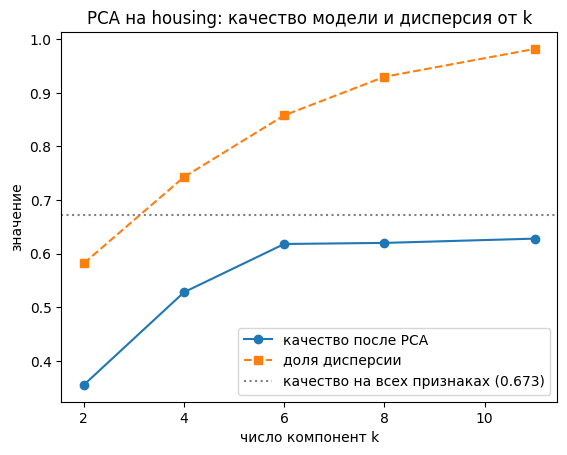

In [18]:
k = [2, 4, 6, 8, 11]
r2_after = [0.355, 0.528, 0.618, 0.620, 0.628]
gamma = [0.582, 0.743, 0.858, 0.930, 0.982]
r2_before = 0.673

fig, ax = plt.subplots()
ax.plot(k, r2_after, 'o-', label='качество после PCA')
ax.plot(k, gamma, 's--', label='доля дисперсии')
ax.axhline(r2_before, color='gray', linestyle=':', label=f'качество на всех признаках ({r2_before})')
ax.set_xlabel('число компонент k')
ax.set_ylabel('значение')
ax.set_title('PCA на housing: качество модели и дисперсия от k')
ax.legend()
plt.show()

уже 6 компонент дают хороший результат (0.618 при 0.673 на всех), при увеличении количества компонент качество увеличивается очень медленно и остается ниже базовой линии. Значит, что необходимые для повышения качества компоненты РСА отбросил первыми(маленькая дисперсия)